In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel("Spring25Project_Data.xlsx")

In [ ]:
coords = df[['x-coordinate', 'y-coordinate']].values
n = len(coords)


In [ ]:
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(coords[i] - coords[j])

In [ ]:
distance_matrix

array([[ 0.        , 40.        , 60.03332408, ..., 42.75511665,
        46.69047012, 38.83297568],
       [40.        ,  0.        , 71.02112362, ...,  8.24621125,
        79.62411695, 75.2861209 ],
       [60.03332408, 71.02112362,  0.        , ..., 78.89233169,
        42.80186912, 50.99019514],
       ...,
       [42.75511665,  8.24621125, 78.89233169, ...,  0.        ,
        85.08818954, 79.84985911],
       [46.69047012, 79.62411695, 42.80186912, ..., 85.08818954,
         0.        , 12.        ],
       [38.83297568, 75.2861209 , 50.99019514, ..., 79.84985911,
        12.        ,  0.        ]])

In [ ]:
demand_df = pd.read_excel("Spring25Project_Data.xlsx", sheet_name="demands")

In [ ]:
total_demand = demand_df['Demand'].sum()

In [ ]:
min_vehicles = int(np.ceil(total_demand / 85))

print(f"Total Demand: {total_demand}")
print(f"Minimum vehicles: {min_vehicles}")

Total Demand: 526
Minimum vehicles: 7


In [ ]:
import networkx as nx
from networkx.algorithms.approximation import christofides
import time

In [ ]:
n = distance_matrix.shape[0]

G = nx.complete_graph(n)

In [ ]:
start_time = time.time()
for i in range(n):
    for j in range(i + 1, n):
        weight = distance_matrix[i][j]
        G[i][j]['weight'] = weight
        G[j][i]['weight'] = weight

chris_tour = christofides(G, weight='weight')

end_time = time.time()
chris_time = end_time - start_time
print(f"Algorithm Time: {chris_time:.7f} saniye")


print("Christofides Tour:", chris_tour)

Algorithm Time: 0.0165629 saniye
Christofides Tour: [0, 26, 5, 9, 28, 29, 24, 15, 3, 38, 12, 37, 31, 14, 35, 25, 2, 7, 8, 19, 33, 4, 16, 10, 27, 34, 22, 18, 21, 23, 17, 36, 1, 11, 6, 32, 20, 30, 13, 0]


In [ ]:
vehicle_capacity = 85
current_capacity = 0
current_route = [0]
all_routes = []

In [ ]:
demands_list = demand_df['Demand'].tolist()

In [ ]:
pure_tour = chris_tour[1:-1]

In [ ]:
start_time = time.time()
for customer in pure_tour:
    demand = demands_list[customer]

    if current_capacity + demand <= vehicle_capacity:
        current_route.append(customer)
        current_capacity += demand
    else:
        current_route.append(0)
        all_routes.append(current_route)
        current_route = [0, customer]
        current_capacity = demand

current_route.append(0)
all_routes.append(current_route)

end_time = time.time()
chrisroute_time = end_time - start_time
print(f"Algorithm Time: {chrisroute_time:.7f} minutes")

for i, route in enumerate(all_routes):
    print(f" {i+1}. Car Route: {route}")

Algorithm Time: 0.0003181 minutes
 1. Car Route: [0, 26, 5, 9, 28, 29, 24, 0]
 2. Car Route: [0, 15, 3, 38, 12, 37, 31, 14, 0]
 3. Car Route: [0, 35, 25, 2, 7, 8, 19, 33, 0]
 4. Car Route: [0, 4, 16, 10, 27, 34, 22, 0]
 5. Car Route: [0, 18, 21, 23, 17, 36, 1, 0]
 6. Car Route: [0, 11, 6, 32, 20, 30, 0]
 7. Car Route: [0, 13, 0]


In [ ]:
def calculate_tour_cost(route, distance_matrix):
    cost = 0
    for i in range(len(route) - 1):
        cost += distance_matrix[route[i]][route[i+1]]
    return cost

In [ ]:
import time
start_time = time.time()

total_vrp_cost = 0
chrisroute_costs = []

for i, route in enumerate(all_routes):
    route_cost = calculate_tour_cost(route, distance_matrix)
    chrisroute_costs.append(route_cost)
    print(f"{i+1}. Car Route Cost: {route_cost:.3f}")
    total_vrp_cost += route_cost

end_time = time.time()
chrisroutecost_time = end_time - start_time

print(f"\nTotal VRP Cost : {total_vrp_cost:.3f}")
print(f"\nAlgorithm Time: {chrisroutecost_time:.7f} minutes")

1. Car Route Cost: 98.138
2. Car Route Cost: 147.727
3. Car Route Cost: 244.281
4. Car Route Cost: 212.760
5. Car Route Cost: 148.249
6. Car Route Cost: 123.836
7. Car Route Cost: 24.331

Total VRP Cost : 999.322

Algorithm Time: 0.0003440 minutes


In [ ]:
def relocation(route, distance_matrix):
    best_route = route.copy()
    best_cost = calculate_tour_cost(route, distance_matrix)
    improved = True

    while improved:
        improved = False
        for i in range(1, len(best_route) - 1):
            for j in range(1, len(best_route) - 1):
                if i == j:
                    continue
                temp_route = best_route.copy()
                customer = temp_route.pop(i)
                temp_route.insert(j, customer)
                temp_cost = calculate_tour_cost(temp_route, distance_matrix)
                if temp_cost < best_cost:
                    best_cost = temp_cost
                    best_route = temp_route
                    improved = True
    return best_route, best_cost


In [ ]:
import time

start_time = time.time()

relocated_routes = []
relocated_costs = []
total_relocated_cost = 0

for i, route in enumerate(all_routes):
    improved_route, improved_cost = relocation(route, distance_matrix)
    relocated_routes.append(improved_route)
    relocated_costs.append(improved_cost)
    print(f"{i+1}. Improved Cost: {improved_cost:.3f}")
    total_relocated_cost += improved_cost

end_time = time.time()
chrisrelocation_time = end_time - start_time

print(f"\nAfter Relocation Cost: {total_relocated_cost:.3f}")
print(f"Relocation Time: {chrisrelocation_time:.7f} minutes")


1. Improved Cost: 98.138
2. Improved Cost: 144.339
3. Improved Cost: 242.821
4. Improved Cost: 212.760
5. Improved Cost: 148.249
6. Improved Cost: 123.836
7. Improved Cost: 24.331

After Relocation Cost: 994.474
Relocation Time: 0.0013189 minutes


<ipython-input-47-d3774c408e02>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(routes))


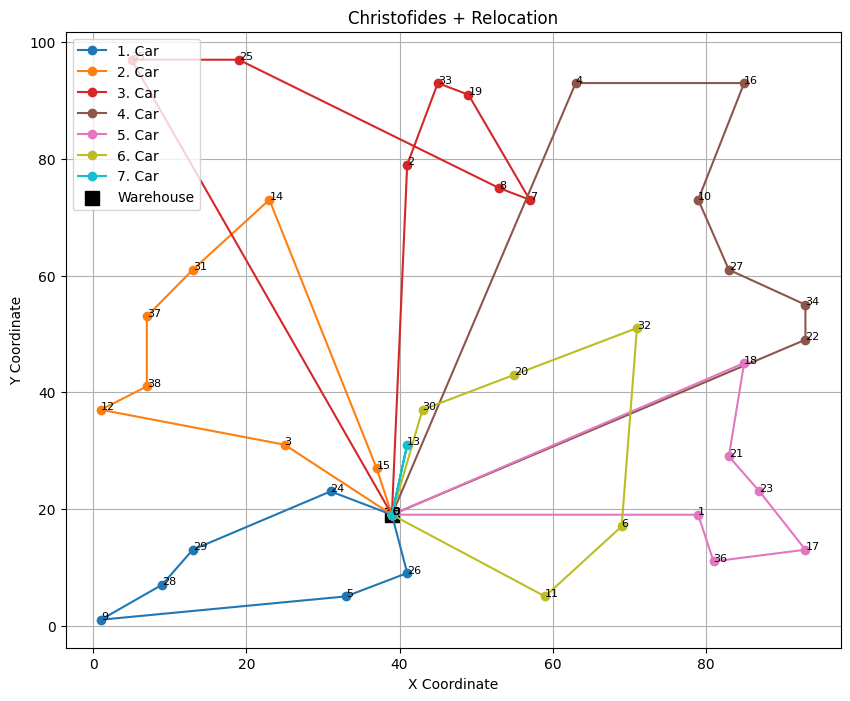

In [ ]:
plot_vrp_routes(relocated_routes, coords, title="Christofides + Relocation")


In [ ]:
verify_vrp_solution(
    routes=relocated_routes,
    demands=demand_df['Demand'].tolist(),
    vehicle_capacity=85,
    n_customers=len(demand_df) - 1
)


VRP solution is verified!!.


True

In [ ]:
chrisrelocationimprovement = 100 * (total_vrp_cost - total_relocated_cost) / total_vrp_cost
print(f"% Improvement: {chrisrelocationimprovement:.5f}%")


% Improvement: 0.48516%


In [ ]:
chrisrelocationtotal_time = chrisroutecost_time + chrisrelocation_time + chris_time + chrisroute_time
print(f"Total Algorithm Time: {chrisrelocationtotal_time:.7f} minutes")

Total Algorithm Time: 0.0185440 minutes


In [ ]:
def two_opt(route, distance_matrix):
    best_route = route.copy()
    best_cost = calculate_tour_cost(best_route, distance_matrix)
    improved = True

    while improved:
        improved = False
        best_i, best_j = None, None

        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                new_route = best_route[:i] + best_route[i:j+1][::-1] + best_route[j+1:]
                new_cost = calculate_tour_cost(new_route, distance_matrix)

                if new_cost < best_cost:
                    best_cost = new_cost
                    best_i, best_j = i, j
                    improved = True

        if improved:
            best_route[best_i:best_j+1] = best_route[best_i:best_j+1][::-1]

    return best_route, best_cost


In [ ]:
import time

chris_2opt_start = time.time()

chris_2opt_routes = []
chris_2opt_costs = []
chris_2opt_total_cost = 0

for i, route in enumerate(all_routes):
    improved_route, improved_cost = two_opt(route, distance_matrix)
    chris_2opt_routes.append(improved_route)
    chris_2opt_costs.append(improved_cost)
    print(f"{i+1}. Car (2-opt) Cost: {improved_cost:.3f}")
    chris_2opt_total_cost += improved_cost

chris_2opt_end = time.time()
chris_2opt_time = chris_2opt_end - chris_2opt_start

print(f"\nChristofides + 2-opt Total Cost: {chris_2opt_total_cost:.3f}")
print(f"Christofides + 2-opt Time: {chris_2opt_time:.7f} minutes")



1. Car (2-opt) Cost: 98.138
2. Car (2-opt) Cost: 144.339
3. Car (2-opt) Cost: 218.331
4. Car (2-opt) Cost: 212.760
5. Car (2-opt) Cost: 148.249
6. Car (2-opt) Cost: 123.836
7. Car (2-opt) Cost: 24.331

Christofides + 2-opt Total Cost: 969.984
Christofides + 2-opt Time: 0.0016398 minutes


In [ ]:
verify_vrp_solution(
    routes=chris_2opt_routes,
    demands=demand_df['Demand'].tolist(),
    vehicle_capacity=85,
    n_customers=len(demand_df) - 1
)


VRP solution is verified!!.


True

<ipython-input-47-d3774c408e02>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(routes))


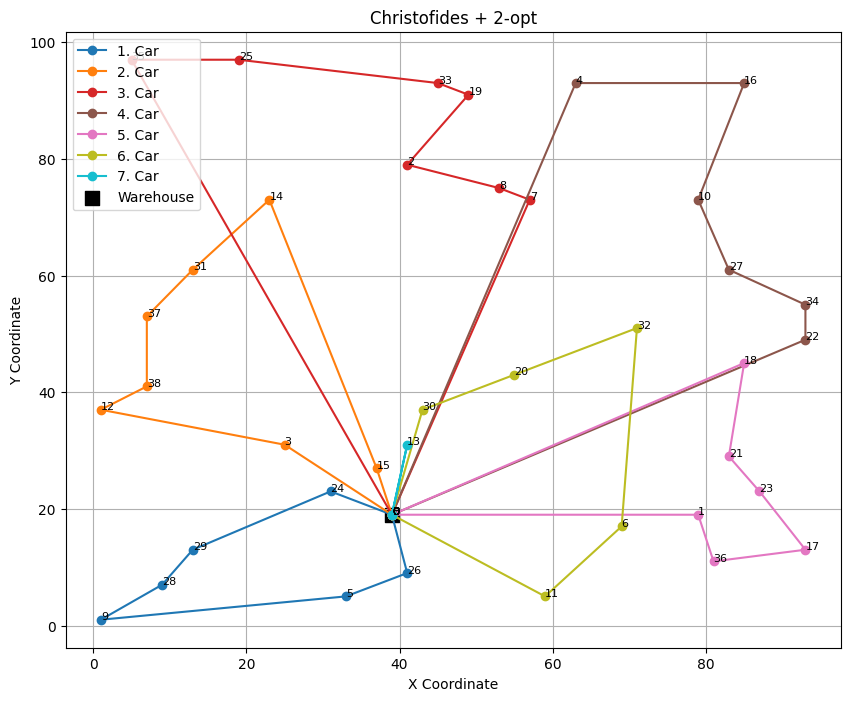

In [ ]:
plot_vrp_routes(chris_2opt_routes, coords, title="Christofides + 2-opt")


In [ ]:
chris_2opt_improvement = 100 * (total_vrp_cost - chris_2opt_total_cost) / total_vrp_cost
print(f"% Improvement (Christofides + 2-opt): {chris_2opt_improvement:.2f}%")

% Improvement (Christofides + 2-opt): 2.94%


In [ ]:
chris_2opttotal_time = chrisroutecost_time + chrisrelocation_time + chris_2opt_time + chris_time + chrisroute_time
print(f"Total Algorithm Time: {chris_2opttotal_time:.7f} minutes")

Total Algorithm Time: 0.0201838 minutes


In [ ]:
import time

print("\n Nearest Neighbor Tour is Creating\n")
nn_reloc_tour_start = time.time()

def nearest_neighbor_tour(distance_matrix, start=0):
    n = len(distance_matrix)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    current = start

    while unvisited:
        next_node = min(unvisited, key=lambda x: distance_matrix[current][x])
        tour.append(next_node)
        unvisited.remove(next_node)
        current = next_node

    tour.append(start)
    return tour

nn_reloc_tour = nearest_neighbor_tour(distance_matrix)

nn_reloc_tour_end = time.time()
nn_reloc_tour_time = nn_reloc_tour_end - nn_reloc_tour_start

print("NN tour:", nn_reloc_tour)
print(f"⏱ NN tour creating time: {nn_reloc_tour_time:.7f} minutes")



 Nearest Neighbor Tour is Creating

NN tour: [0, 15, 13, 30, 20, 32, 18, 22, 34, 27, 10, 16, 4, 19, 33, 2, 8, 7, 14, 31, 37, 38, 12, 3, 24, 26, 5, 29, 28, 9, 11, 6, 1, 36, 17, 23, 21, 25, 35, 0]
⏱ NN tour creating time: 0.0005164 minutes


In [ ]:
print("\n NN with Capaticy...\n")

nn_reloc_split_start = time.time()

vehicle_capacity = 85
nn_reloc_all_routes = []
current_route = [0]
current_capacity = 0

demands_list = demand_df['Demand'].tolist()
pure_tour = nn_reloc_tour[1:-1]

for node in pure_tour:
    demand = demands_list[node]
    if current_capacity + demand <= vehicle_capacity:
        current_route.append(node)
        current_capacity += demand
    else:
        current_route.append(0)
        nn_reloc_all_routes.append(current_route)


        current_route = [0, node]
        current_capacity = demand


current_route.append(0)
nn_reloc_all_routes.append(current_route)

nn_reloc_split_end = time.time()
nn_reloc_split_time = nn_reloc_split_end - nn_reloc_split_start


for i, r in enumerate(nn_reloc_all_routes):
    print(f" {i+1}. Car Route : {r}")

print(f"\n total route :{len(nn_reloc_all_routes)} ")
print(f" Time: {nn_reloc_split_time:.7f} minutes")



 NN with Capaticy...

 1. Car Route : [0, 15, 0]
 2. Car Route : [0, 13, 30, 0]
 3. Car Route : [0, 20, 32, 18, 22, 34, 27, 10, 0]
 4. Car Route : [0, 16, 4, 19, 33, 0]
 5. Car Route : [0, 2, 8, 7, 14, 31, 37, 38, 12, 0]
 6. Car Route : [0, 3, 24, 26, 5, 29, 0]
 7. Car Route : [0, 28, 9, 11, 6, 1, 36, 17, 0]
 8. Car Route : [0, 23, 21, 25, 35, 0]

 total route :8 
 Time: 0.0004671 minutes


In [ ]:
print("\nNN with cost\n")

nn_reloc_cost_start = time.time()

nn_reloc_costs = []
nn_reloc_total_cost = 0

for i, route in enumerate(nn_reloc_all_routes):
    route_cost = calculate_tour_cost(route, distance_matrix)
    nn_reloc_costs.append(route_cost)
    print(f"{i+1}. Car Cost : {route_cost:.3f}")
    nn_reloc_total_cost += route_cost

nn_reloc_cost_end = time.time()
nn_reloc_cost_time = nn_reloc_cost_end - nn_reloc_cost_start

print(f"\n NN Total Cost: {nn_reloc_total_cost:.3f}")
print(f" NN Total Cost Time: {nn_reloc_cost_time:.7f} minutes")



NN with cost

1. Car Cost : 16.492
2. Car Cost : 36.929
3. Car Cost : 168.421
4. Car Cost : 201.989
5. Car Cost : 198.034
6. Car Cost : 102.812
7. Car Cost : 201.011
8. Car Cost : 247.847

 NN Total Cost: 1173.535
 NN Total Cost Time: 0.0002654 minutes


In [ ]:
print("\n NN + Relocation \n")

nn_reloc_improve_start = time.time()

nn_reloc_routes = []
nn_reloc_improved_costs = []
nn_reloc_improved_total_cost = 0

for i, route in enumerate(nn_reloc_all_routes):
    improved_route, improved_cost = relocation(route, distance_matrix)
    nn_reloc_routes.append(improved_route)
    nn_reloc_improved_costs.append(improved_cost)
    print(f"{i+1}. Car improved cost: {improved_cost:.3f}")
    nn_reloc_improved_total_cost += improved_cost

nn_reloc_improve_end = time.time()
nn_reloc_improve_time = nn_reloc_improve_end - nn_reloc_improve_start



 NN + Relocation 

1. Car improved cost: 16.492
2. Car improved cost: 36.929
3. Car improved cost: 162.237
4. Car improved cost: 201.989
5. Car improved cost: 179.895
6. Car improved cost: 81.261
7. Car improved cost: 195.742
8. Car improved cost: 247.847


In [ ]:
verify_vrp_solution(
    routes=nn_reloc_routes,
    demands=demand_df['Demand'].tolist(),
    vehicle_capacity=85,
    n_customers=len(demand_df) - 1  # depo hariç müşteri sayısı
)


VRP solution is verified!!.


True

<ipython-input-47-d3774c408e02>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(routes))


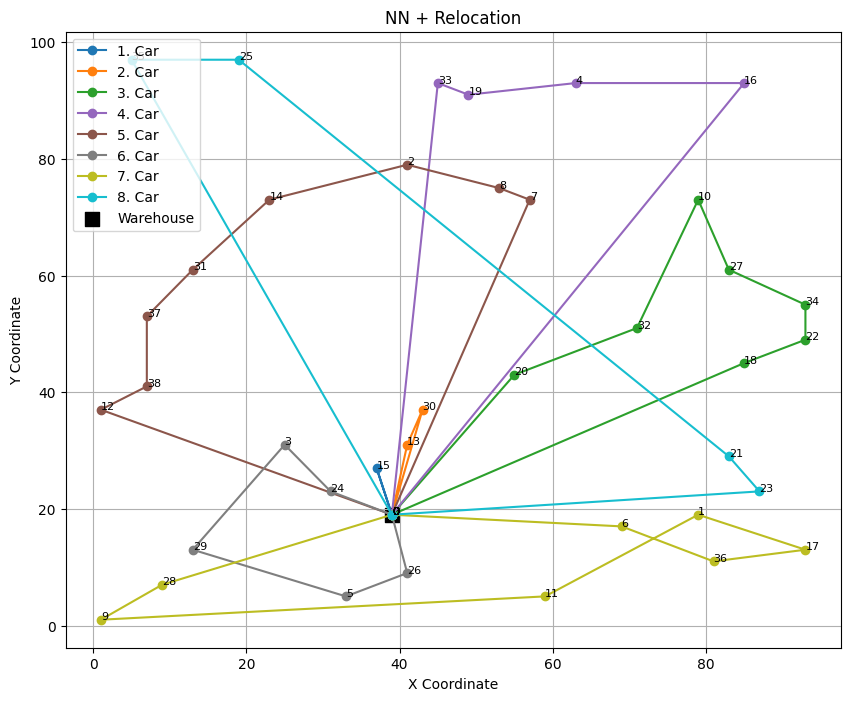

In [ ]:
plot_vrp_routes(nn_reloc_routes, coords, title="NN + Relocation")


In [ ]:
print(f"\n NN + Relocation Cost: {nn_reloc_improved_total_cost:.3f}")
print(f"Relocation Time: {nn_reloc_improve_time:.7f} minutes")

nn_reloc_percent_improvement = 100 * (nn_reloc_total_cost - nn_reloc_improved_total_cost) / nn_reloc_total_cost
print(f" % Improvement (Relocation): {nn_reloc_percent_improvement:.2f}%")



 NN + Relocation Cost: 1122.392
Relocation Time: 0.0017316 minutes
 % Improvement (Relocation): 4.36%


In [ ]:
nn_reloctotal_time = nn_reloc_cost_time + nn_reloc_improve_time + nn_reloc_split_time + nn_reloc_tour_time
print(f"Total algorithm time: {nn_reloctotal_time:.7f} minutes")

Total algorithm time: 0.0029805 minutes


In [ ]:
import time

print("\n NN + 2-Opt\n")

nn_2opt_start = time.time()

nn_2opt_routes = []
nn_2opt_total_cost = 0

for i, route in enumerate(nn_reloc_all_routes):
    improved_route, improved_cost = two_opt(route, distance_matrix)
    nn_2opt_routes.append(improved_route)
    nn_2opt_total_cost += improved_cost
    print(f"Araç {i+1}. Car (after 2-opt) cost: {improved_cost:.3f}")

nn_2opt_end = time.time()
nn_2opt_time = nn_2opt_end - nn_2opt_start



 NN + 2-Opt

Araç 1. Car (after 2-opt) cost: 16.492
Araç 2. Car (after 2-opt) cost: 36.929
Araç 3. Car (after 2-opt) cost: 162.237
Araç 4. Car (after 2-opt) cost: 201.989
Araç 5. Car (after 2-opt) cost: 179.895
Araç 6. Car (after 2-opt) cost: 81.261
Araç 7. Car (after 2-opt) cost: 190.914
Araç 8. Car (after 2-opt) cost: 247.847


In [ ]:
verify_vrp_solution(
    routes=nn_2opt_routes,
    demands=demand_df['Demand'].tolist(),
    vehicle_capacity=85,
    n_customers=len(demand_df) - 1
)


VRP solution is verified!!.


True

<ipython-input-47-d3774c408e02>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(routes))


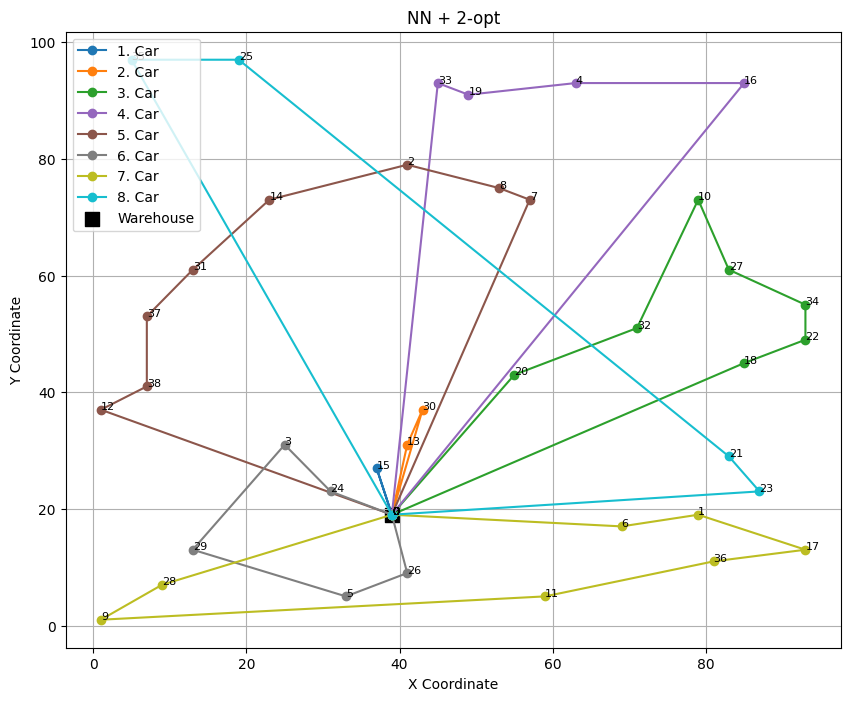

In [ ]:
plot_vrp_routes(nn_2opt_routes, coords, title="NN + 2-opt")


In [ ]:
nn_2opt_original_cost = sum([calculate_tour_cost(r, distance_matrix) for r in nn_reloc_all_routes])
nn_2opt_improvement = 100 * (nn_2opt_original_cost - nn_2opt_total_cost) / nn_2opt_original_cost


In [ ]:
nn_2opt_total_time = nn_reloc_tour_time + nn_reloc_split_time + nn_2opt_time + nn_reloc_cost_time
print(f"NN + 2-opt Total Algorithm time: {nn_2opt_total_time:.7f} minutes")



NN + 2-opt Total Algorithm time: 0.0036089 minutes


In [ ]:
print(f" NN + 2-opt before cost: {nn_2opt_original_cost:.3f}")
print(f" NN + 2-opt after cost: {nn_2opt_total_cost:.3f}")
print(f" % improvement: {nn_2opt_improvement:.2f}%")


 NN + 2-opt before cost: 1173.535
 NN + 2-opt after cost: 1117.564
 % improvement: 4.77%


In [ ]:
chrisrelocationimprovement , chrisrelocationtotal_time , total_relocated_cost
chris_2opttotal_time , chris_2opt_improvement , chris_2opt_total_cost
nn_reloc_percent_improvement , nn_reloctotal_time , nn_reloc_improved_total_cost
nn_2opt_improvement , nn_2opt_total_time , nn_2opt_total_cost


(np.float64(4.769471525799708),
 0.0036089420318603516,
 np.float64(1117.564043853491))

In [ ]:
print(" VRP Algorithm Table")
print("-" * 70)
print(f"{'Combination':35} {'Final Cost':>12} {'Time (s)':>12} {'% Improve':>12}")
print("-" * 70)

print(f"{'Christofides + Relocation':35} {total_relocated_cost:12.3f} {chrisrelocationtotal_time:12.7f} {chrisrelocationimprovement:12.5f}")
print(f"{'Christofides + 2-opt':35} {chris_2opt_total_cost:12.3f} {chris_2opttotal_time:12.7f} {chris_2opt_improvement:12.5f}")
print(f"{'Nearest Neighbor + Relocation':35} {nn_reloc_improved_total_cost:12.3f} {nn_reloctotal_time:12.7f} {nn_reloc_percent_improvement:12.5f}")
print(f"{'Nearest Neighbor + 2-opt':35} {nn_2opt_total_cost:12.3f} {nn_2opt_total_time:12.7f} {nn_2opt_improvement:12.5f}")
print("-" * 70)


 VRP Algorithm Table
----------------------------------------------------------------------
Combination                           Final Cost     Time (s)    % Improve
----------------------------------------------------------------------
Christofides + Relocation                994.474    0.0185440      0.48516
Christofides + 2-opt                     969.984    0.0201838      2.93582
Nearest Neighbor + Relocation           1122.392    0.0029805      4.35807
Nearest Neighbor + 2-opt                1117.564    0.0036089      4.76947
----------------------------------------------------------------------


In [ ]:
def calculate_utilization(routes, demands, vehicle_capacity):
    print(f"\n Vehicle Utilization (%):\n")
    for i, route in enumerate(routes):
        load = sum(demands[node] for node in route if node != 0)
        utilization = (load / vehicle_capacity) * 100
        print(f"{i+1:<2}. Car: {load:3} / {vehicle_capacity} → % {utilization:.2f}")


In [ ]:
print("Christofides + 2-Opt\n")
calculate_utilization(chris_2opt_routes, demand_df['Demand'].tolist(), 85)


Christofides + 2-Opt


 Vehicle Utilization (%):

Araç 1 :  73 / 85 → % 85.88
Araç 2 :  83 / 85 → % 97.65
Araç 3 :  83 / 85 → % 97.65
Araç 4 :  80 / 85 → % 94.12
Araç 5 :  71 / 85 → % 83.53
Araç 6 :  64 / 85 → % 75.29
Araç 7 :  72 / 85 → % 84.71


In [ ]:
print("Christofides + Relocation Utilization\n")
calculate_utilization(relocated_routes, demand_df['Demand'].tolist(), 85)

Christofides + Relocation Utilization


 Vehicle Utilization (%):

Araç 1 :  73 / 85 → % 85.88
Araç 2 :  83 / 85 → % 97.65
Araç 3 :  83 / 85 → % 97.65
Araç 4 :  80 / 85 → % 94.12
Araç 5 :  71 / 85 → % 83.53
Araç 6 :  64 / 85 → % 75.29
Araç 7 :  72 / 85 → % 84.71


In [ ]:
print("NN + Relocation Utilization\n")
calculate_utilization(nn_reloc_routes, demand_df['Demand'].tolist(), 85)

NN + Relocation Utilization


 Vehicle Utilization (%):

Araç 1 :  16 / 85 → % 18.82
Araç 2 :  81 / 85 → % 95.29
Araç 3 :  73 / 85 → % 85.88
Araç 4 :  79 / 85 → % 92.94
Araç 5 :  73 / 85 → % 85.88
Araç 6 :  84 / 85 → % 98.82
Araç 7 :  85 / 85 → % 100.00
Araç 8 :  35 / 85 → % 41.18


In [ ]:
print("NN + 2-Opt Utilization\n")
calculate_utilization(nn_2opt_routes, demand_df['Demand'].tolist(), 85)

NN + 2-Opt Utilization


 Vehicle Utilization (%):

Araç 1 :  16 / 85 → % 18.82
Araç 2 :  81 / 85 → % 95.29
Araç 3 :  73 / 85 → % 85.88
Araç 4 :  79 / 85 → % 92.94
Araç 5 :  73 / 85 → % 85.88
Araç 6 :  84 / 85 → % 98.82
Araç 7 :  85 / 85 → % 100.00
Araç 8 :  35 / 85 → % 41.18


In [ ]:
def inter_route_2exchange(routes, distance_matrix):
    best_routes = [r.copy() for r in routes]
    best_cost = sum(calculate_tour_cost(r, distance_matrix) for r in best_routes)
    improved = True

    while improved:
        improved = False
        for i in range(len(best_routes)):
            for j in range(i + 1, len(best_routes)):
                route1 = best_routes[i]
                route2 = best_routes[j]

                for idx1 in range(1, len(route1) - 1):
                    for idx2 in range(1, len(route2) - 1):

                        new_route1 = route1.copy()
                        new_route2 = route2.copy()
                        new_route1[idx1], new_route2[idx2] = new_route2[idx2], new_route1[idx1]
                        new_cost1 = calculate_tour_cost(new_route1, distance_matrix)
                        new_cost2 = calculate_tour_cost(new_route2, distance_matrix)

                        other_cost = sum(
                            calculate_tour_cost(best_routes[k], distance_matrix)
                            for k in range(len(best_routes)) if k != i and k != j
                        )

                        new_total_cost = new_cost1 + new_cost2 + other_cost

                        if new_total_cost < best_cost:
                            best_cost = new_total_cost
                            best_routes[i] = new_route1
                            best_routes[j] = new_route2
                            improved = True

    return best_routes, best_cost


In [ ]:
import time


chris_2opt_2exchange_start = time.time()

chris_2opt_2exchange_routes, chris_2opt_2exchange_cost = inter_route_2exchange(chris_2opt_routes, distance_matrix)

chris_2opt_2exchange_end = time.time()
chris_2opt_2exchange_time = chris_2opt_2exchange_end - chris_2opt_2exchange_start


improvement_chris_2opt_2exchange = 100 * (chris_2opt_total_cost - chris_2opt_2exchange_cost) / chris_2opt_total_cost


print(f" Before Cost (Christofides + 2-opt): {chris_2opt_total_cost:.3f}")
print(f" After 2-Exchange Cost           : {chris_2opt_2exchange_cost:.3f}")
print(f" % Improvement (2-Exchange)           : {improvement_chris_2opt_2exchange:.5f}%")
print(f" 2-Exchange algortihm time        : {chris_2opt_2exchange_time:.7f} minutes")


print("\n in car cost compare:\n")
print(f"{'Car':<6}{'2-opt Cost':>15}{'2-Exchange Cost':>20}")
print("-" * 45)

for i in range(len(chris_2opt_routes)):
    cost_before = calculate_tour_cost(chris_2opt_routes[i], distance_matrix)
    cost_after = calculate_tour_cost(chris_2opt_2exchange_routes[i], distance_matrix)
    print(f"{i+1:<6}{cost_before:15.3f}{cost_after:20.3f}")



 Before Cost (Christofides + 2-opt): 969.984
 After 2-Exchange Cost           : 938.066
 % Improvement (2-Exchange)           : 3.29056%
 2-Exchange algortihm time        : 0.0897989 minutes

 in car cost compare:

Car        2-opt Cost     2-Exchange Cost
---------------------------------------------
1              98.138              98.138
2             144.339             145.869
3             218.331             218.331
4             212.760             212.760
5             148.249             120.253
6             123.836             126.222
7              24.331              16.492


In [ ]:
def verify_vrp_solution(routes, demands, vehicle_capacity, n_customers):
    visited_customers = set()
    valid = True

    for i, route in enumerate(routes):
        if route[0] != 0 or route[-1] != 0:
            print(f" {i+1}. Car: Route is not start or end with Warehouse! → {route}")
            valid = False

        total_demand = 0
        for node in route[1:-1]:
            if node == 0:
                print(f" {i+1}. Car: Warehouse is existing in the middle of route! → {route}")
                valid = False
            total_demand += demands[node]
            if node in visited_customers:
                print(f" {node}. Customer visited more than 1!")
                valid = False
            else:
                visited_customers.add(node)

        if total_demand > vehicle_capacity:
            print(f"{i+1}. Car: Capacity was noble → {total_demand} > {vehicle_capacity}")
            valid = False


    if len(visited_customers) != n_customers:
        print(f"All Customer is not visited. Expected: {n_customers}, Real: {len(visited_customers)}")
        valid = False

    if valid:
        print("VRP solution is verified!!.")
    return valid


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_vrp_routes(routes, coords, title="VRP Solution"):
    plt.figure(figsize=(10, 8))
    colors = plt.cm.get_cmap("tab10", len(routes))

    for i, route in enumerate(routes):
        x = [coords[node][0] for node in route]
        y = [coords[node][1] for node in route]
        plt.plot(x, y, marker='o', label=f"{i+1}. Car", color=colors(i))


        for node in route:
            plt.text(coords[node][0], coords[node][1], str(node), fontsize=8)


    depot_x, depot_y = coords[0]
    plt.scatter(depot_x, depot_y, color='black', marker='s', s=100, label='Warehouse')

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True)
    plt.show()


<ipython-input-47-d3774c408e02>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(routes))


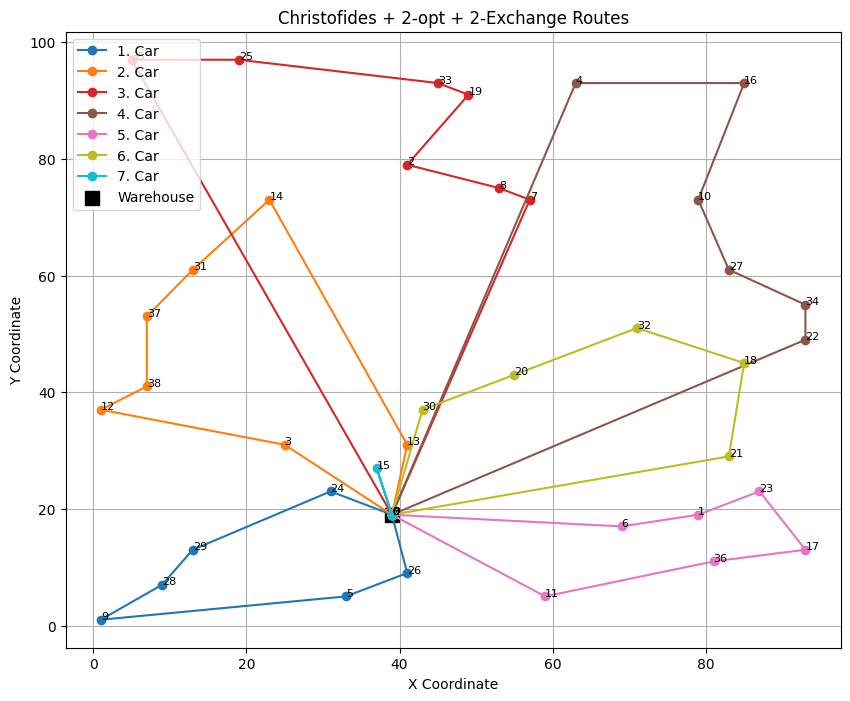

In [ ]:
plot_vrp_routes(chris_2opt_2exchange_routes, coords, title="Christofides + 2-opt + 2-Exchange Routes")
